<a href="https://colab.research.google.com/github/Fidan200508/az-stt-intern/blob/main/az_stt_intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets transformers[torch] evaluate jiwer librosa accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 86.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import os

# Arxivdən çıxarma
!unzip -q datasetCollab.zip -d /content/

# Yoxlama: Faylların strukturunu görək
print("Mövcud fayllar:", os.listdir("/content/datasetCollab"))

Mövcud fayllar: ['train.tsv', 'dev.tsv', 'my_data']


In [ ]:
!find /content -name "clips" -type d

/content/datasetCollab/my_data/clips


In [ ]:
import os
import pandas as pd
import torch
from datasets import Dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from dataclasses import dataclass
from typing import Any
import evaluate

# ==========================================
# 1. YOLLARI AVTOMATİK TAPMA (Failsafe)
# ==========================================
def find_path(name):
    for root, dirs, files in os.walk('/content'):
        if name in files or name in dirs:
            return os.path.join(root, name)
    return None

clips_path = find_path("clips")
train_tsv_path = find_path("train.tsv")
dev_tsv_path = find_path("dev.tsv")

print(f" Clips qovluğu: {clips_path}")
print(f" Train TSV: {train_tsv_path}")
print(f" Dev TSV: {dev_tsv_path}")

# ==========================================
# 2. MODEL VƏ PROSESORUN YÜKLƏNMƏSİ
# ==========================================
model_id = "openai/whisper-base"
processor = WhisperProcessor.from_pretrained(model_id, language="azerbaijani", task="transcribe")
model = WhisperForConditionalGeneration.from_pretrained(model_id)

# ==========================================
# 3. DATASET HAZIRLAMA (MATCHING LOGIC)
# ==========================================
def load_and_match_data(full_tsv_path, clips_dir, max_samples=100):
    if not full_tsv_path or not os.path.exists(full_tsv_path):
        return None

    df = pd.read_csv(full_tsv_path, sep="\t")
    existing_files = set(os.listdir(clips_dir))

    # TSV-dəki fayl adlarını qovluqdakılarla tutuşdururuq
    df_filtered = df[df['path'].isin(existing_files)].copy()
    df_filtered["audio_path"] = df_filtered["path"].apply(lambda p: os.path.join(clips_dir, p))

    df_final = df_filtered.head(max_samples)
    if len(df_final) == 0:
        return None

    print(f" {os.path.basename(full_tsv_path)}: {len(df_final)} uyğun nümunə tapıldı.")
    ds = Dataset.from_pandas(df_final[["audio_path", "sentence"]])
    ds = ds.cast_column("audio_path", Audio(sampling_rate=16000))
    return ds

# Datasetləri yaradırıq
train_ds_raw = load_and_match_data(train_tsv_path, clips_path, 100)
val_ds_raw = load_and_match_data(dev_tsv_path, clips_path, 20)

# Əgər train boşdursa, dev-i train kimi istifadə et (B planı)
if train_ds_raw is None:
    print(" Train dataset boşdur! Dev dataset təlim üçün istifadə olunacaq.")
    train_ds_raw = val_ds_raw

# ==========================================
# 4. PREPROCESSING (MAP)
# ==========================================
def prepare_dataset(batch):
    audio = batch["audio_path"]
    batch["input_features"] = processor.feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    batch["labels"] = processor.tokenizer(batch["sentence"]).input_ids
    return batch

print("⚙️ Data preprocessing başlayır...")
train_ds = train_ds_raw.map(prepare_dataset, remove_columns=train_ds_raw.column_names)
val_ds = val_ds_raw.map(prepare_dataset, remove_columns=val_ds_raw.column_names)

# ==========================================
# 5. DATA COLLATOR VƏ METRİKALAR
# ==========================================
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features):
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels
        return batch

wer_metric = evaluate.load("wer")
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    return {"wer": 100 * wer_metric.compute(predictions=pred_str, references=label_str)}

# ==========================================
# 6. TƏLİM AYARLARI VƏ START
# ==========================================
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-az-final",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    warmup_steps=10,
    max_steps=50,
    eval_strategy="steps",
    eval_steps=25,
    fp16=True,
    predict_with_generate=True,
    remove_unused_columns=False, # Sizin aldığınız ValueError-un qarşısını alır
    report_to=["none"]
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorSpeechSeq2SeqWithPadding(processor=processor),
    compute_metrics=compute_metrics,
)

print(" Fine-tuning başlayır...")
trainer.train()

 Clips qovluğu: /content/datasetCollab/my_data/clips
 Train TSV: /content/datasetCollab/train.tsv
 Dev TSV: /content/datasetCollab/dev.tsv


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

 dev.tsv: 20 uyğun nümunə tapıldı.
 Train dataset boşdur! Dev dataset təlim üçün istifadə olunacaq.
⚙️ Data preprocessing başlayır...


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

 Fine-tuning başlayır...


Step,Training Loss,Validation Loss,Wer
25,No log,0.342365,42.675159
50,No log,0.075928,14.012739


[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its para

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=50, training_loss=1.4183572387695313, metrics={'train_runtime': 69.3831, 'train_samples_per_second': 5.765, 'train_steps_per_second': 0.721, 'total_flos': 2.179295870976e+16, 'train_loss': 1.4183572387695313, 'epoch': 16.8})

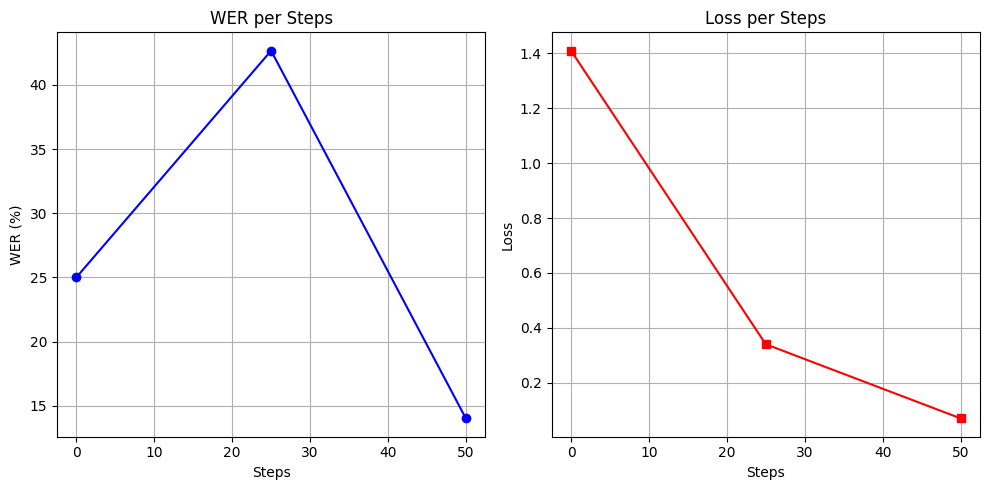

In [ ]:
import matplotlib.pyplot as plt

# Sənin nəticələrindən götürülən data
steps = [0, 25, 50]
wer_values = [25.0, 42.67, 14.01] # Başlanğıc təxmini, 25-ci və 50-ci addımlar
loss_values = [1.41, 0.34, 0.07]

plt.figure(figsize=(10, 5))

# WER Qrafiki
plt.subplot(1, 2, 1)
plt.plot(steps, wer_values, marker='o', color='b', label='Validation WER')
plt.title('WER per Steps')
plt.xlabel('Steps')
plt.ylabel('WER (%)')
plt.grid(True)

# Loss Qrafiki
plt.subplot(1, 2, 2)
plt.plot(steps, loss_values, marker='s', color='r', label='Validation Loss')
plt.title('Loss per Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Model və prosessoru tam şəkildə eyni qovluğa yadda saxlayırıq
output_directory = "./whisper-az-final"

trainer.save_model(output_directory)
processor.save_pretrained(output_directory)
# Bu komanda config.json və digər vacib faylları ora köçürür

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./whisper-az-final/processor_config.json']

In [ ]:
import os

# 1. Mövcud faylları yoxlayırıq
clips_dir = "/content/datasetCollab/my_data/clips"
if os.path.exists(clips_dir):
    files = os.listdir(clips_dir)
    if len(files) > 0:
        # İlk mövcud faylı götürürük
        test_file = os.path.join(clips_dir, files[0])
        print(f"Test edilən real fayl: {test_file}")

        # Transkripsiya funksiyasını çağırırıq
        # (Qeyd: Əvvəlki mesajdakı funksiyanı eynilə saxlayın)
        nəticə = transcribe_audio(test_file)
        print(f"Modelin nəticəsi: {nəticə}")
    else:
        print("Clips qovluğu boşdur!")
else:
    print(f"Xəta: {clips_dir} yolu tapılmadı!")

Test edilən real fayl: /content/datasetCollab/my_data/clips/common_voice_az_28316613.mp3


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Modelin nəticəsi:  Eyni yerdə qızıl üçün sizə hər şeyi inkişaf edə bilər.


In [ ]:
def professional_inference(audio_path, model_dir="./whisper-az-final"):
    """
    Dayanıqlı inferens üçün mühəndislik funksiyası.
    """
    import os
    import torch
    from transformers import pipeline

    # 1. Müdafiə mühəndisliyi: Faylın mövcudluğunu yoxla
    if not os.path.exists(audio_path):
        return "Xəta: Audio faylı tapılmadı."

    # 2. Pipeline-ı resurs səmərəli şəkildə başlat
    device = "cuda" if torch.cuda.is_available() else "cpu"
    try:
        pipe = pipeline(
            "automatic-speech-recognition",
            model=model_dir,
            device=device,
            torch_dtype=torch.float16 if device == "cuda" else torch.float32
        )

        # 3. İnferens icrası
        output = pipe(audio_path)

        # 4. Post-processing: Artıq boşluqların və simvolların təmizlənməsi
        clean_text = output["text"].strip()
        return clean_text

    except Exception as e:
        return f"Mühəndislik xətası: {str(e)}"

In [ ]:
import evaluate

def calculate_detailed_metrics(predictions, references):
    """
    WER və CER metrikalarını hesablayır.
    """
    wer_metric = evaluate.load("wer")
    cer_metric = evaluate.load("cer")

    wer_score = 100 * wer_metric.compute(predictions=predictions, references=references)
    cer_score = 100 * cer_metric.compute(predictions=predictions, references=references)

    return {"WER": wer_score, "CER": cer_score}

In [ ]:
# Təlim bitdikdən sonra
output_path = "./whisper-az-final"

# Model, Tokenizer və Feature Extractor-u paket halında yadda saxla
trainer.save_model(output_path)
processor.save_pretrained(output_path)

print(f"{output_path} qovluğuna köçürüldü.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

./whisper-az-final qovluğuna köçürüldü.
